# Chapter 17: Living with Probability
Forecast distributions express uncertainty conditional on assumptions. We compute
a random-walk fan, repeated coverage, and interval scores on synthetic outcomes.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
from scipy.stats import norm
rng=begin(17)

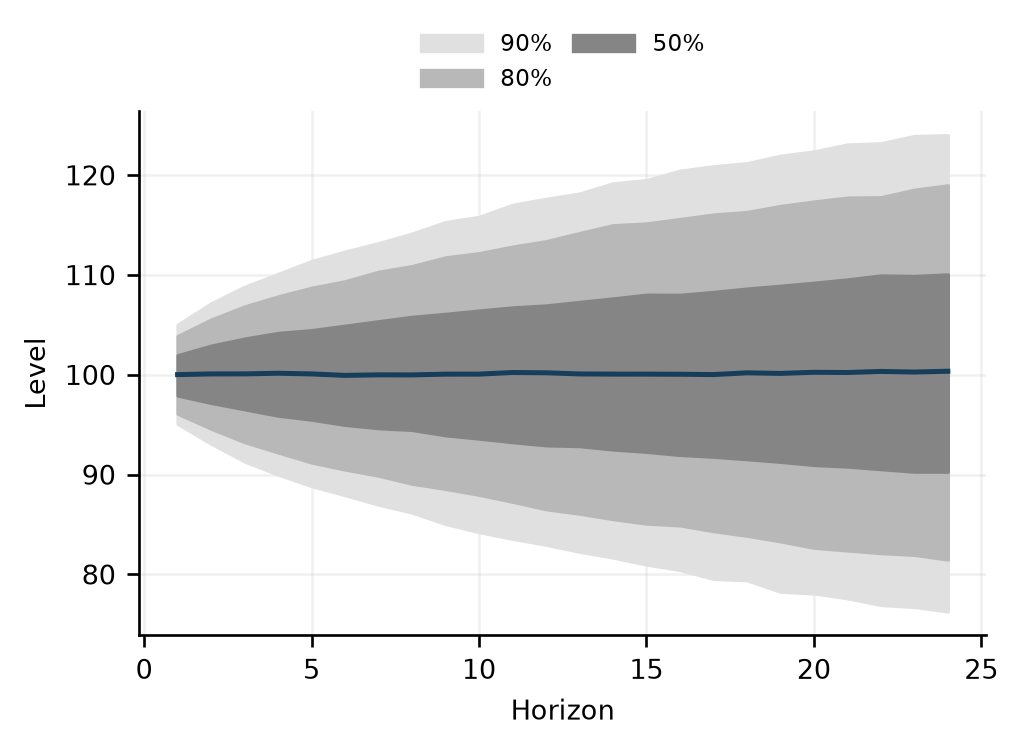

In [2]:
paths=100+np.cumsum(rng.normal(0,3,(6000,24)),axis=1); horizon=np.arange(1,25)
plt.figure()
for coverage,alpha in [(.9,.15),(.8,.2),(.5,.35)]:
    lo,hi=np.quantile(paths,[(1-coverage)/2,(1+coverage)/2],axis=0)
    plt.fill_between(horizon,lo,hi,color={.9:'.88',.8:'.72',.5:'.52'}[coverage],label=f'{coverage:.0%}')
plt.plot(horizon,np.median(paths,axis=0)); plt.xlabel('Horizon'); plt.ylabel('Level'); plt.legend()
save(17,1,'Uncertainty widens with the horizon','Synthetic random-walk predictive quantiles, conditional on independent normal increments with known standard deviation.','## Section Three: What Probabilistic Forecasting Actually Is')

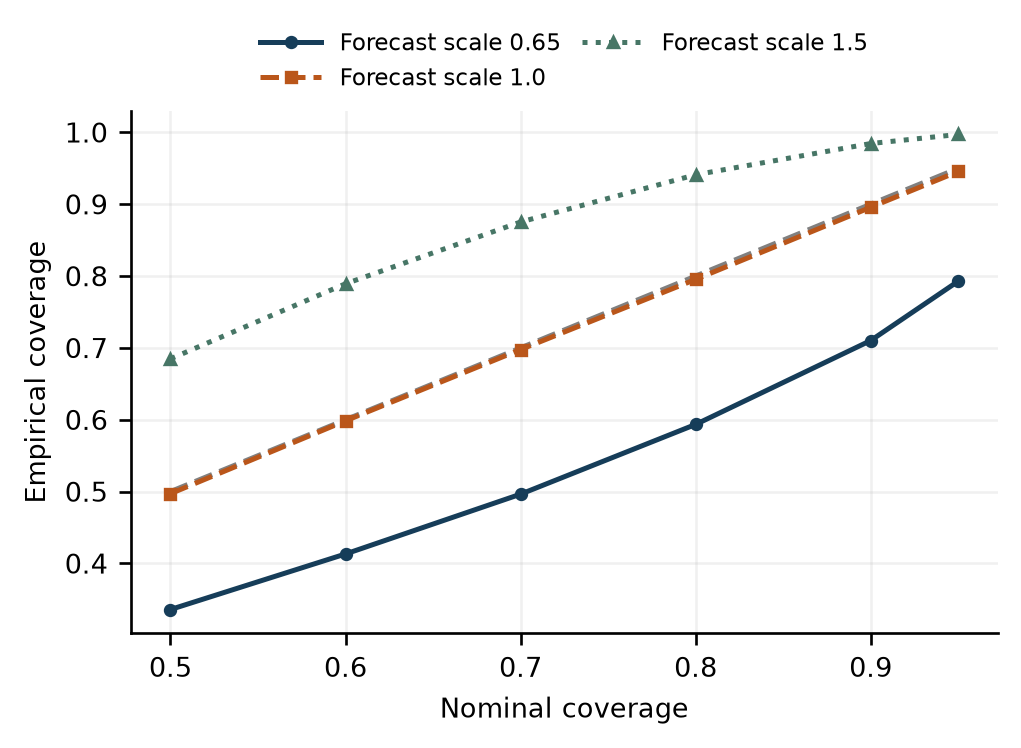

In [3]:
nominal=np.array([.5,.6,.7,.8,.9,.95]); actual=rng.normal(size=20000)
plt.figure(); plt.plot(nominal,nominal,'--',color='.5')
for scale in [.65,1.,1.5]:
    coverage=[np.mean(abs(actual)<=scale*norm.ppf((1+c)/2)) for c in nominal]
    plt.plot(nominal,coverage,'o-',label=f'Forecast scale {scale}')
plt.xlabel('Nominal coverage'); plt.ylabel('Empirical coverage'); plt.legend(fontsize=7)
save(17,2,'An interval must earn its stated coverage','Twenty thousand synthetic standard-normal outcomes. Narrow distributions under-cover; overly broad distributions over-cover.','## Section Four: The Full Methodology')

## Width alone is not enough
The interval score is width plus penalties for outcomes outside the interval.
At nominal 80% coverage, each miss is penalized by 2/0.2 times its distance.

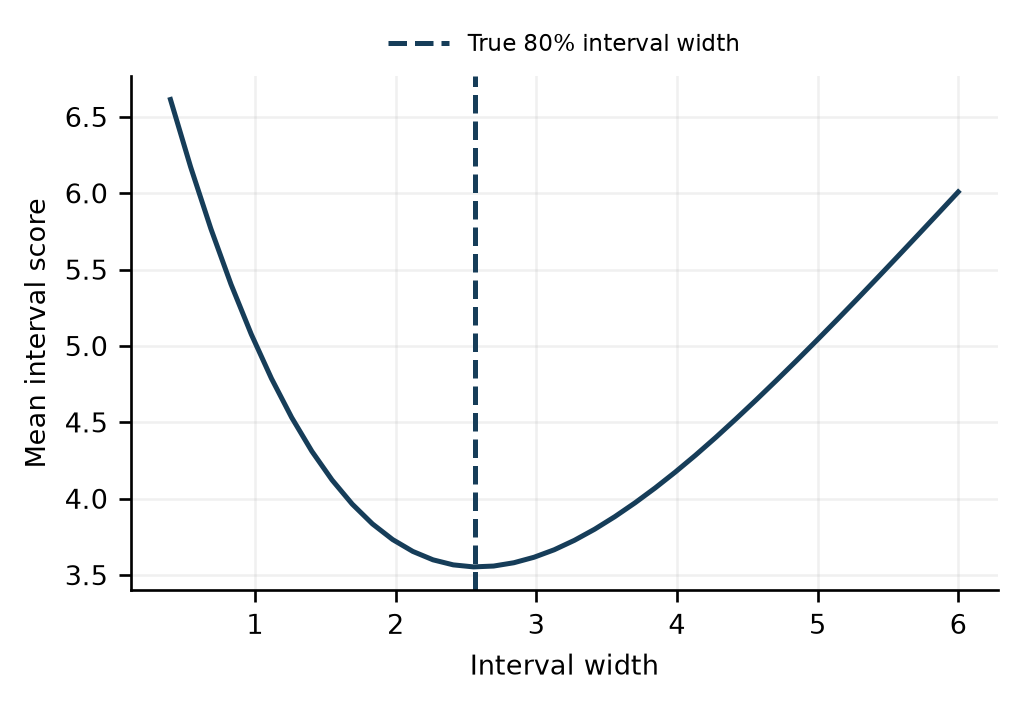

Underdispersed forecast PIT tail mass: 0.4065
Mean pinball loss at q=.9: 0.17767966341140987


In [4]:
widths=np.linspace(.2,3,40); scores=[]
for halfwidth in widths:
    lo,hi=-halfwidth,halfwidth
    scores.append(np.mean(hi-lo+10*np.maximum(lo-actual,0)+10*np.maximum(actual-hi,0)))
plt.figure(); plt.plot(2*widths,scores); plt.axvline(2*norm.ppf(.9),ls='--',label='True 80% interval width'); plt.xlabel('Interval width'); plt.ylabel('Mean interval score'); plt.legend(fontsize=7)
save(17,3,'Reward useful width and penalize missed outcomes','Synthetic standard-normal outcomes scored at an 80% nominal level. Arbitrarily wide intervals pay a width penalty.','## Section Five: Reader Connection')
pit=norm.cdf(actual/.65); print('Underdispersed forecast PIT tail mass:',np.mean((pit<.1)|(pit>.9)))
q=norm.ppf(.9); print('Mean pinball loss at q=.9:',np.mean(np.maximum(.9*(actual-q),-.1*(actual-q))))

## Calibrate using an earlier time block
Fit an AR coefficient on training data, freeze it, and compute absolute one-step
residuals on a later calibration block. The corrected rank is ceil((n+1)(1-alpha)):
ordinary interpolated sample quantiles do not implement this finite-sample rule.
Serial dependence remains, so the exchangeable split-conformal guarantee does
NOT automatically apply. Report empirical coverage on a still-later test block.

In [5]:
ordered = np.zeros(241)
for index in range(1, len(ordered)):
    ordered[index] = .7*ordered[index-1]+rng.normal()
train_end, calibration_end = 80,160
coefficient = float(ordered[:train_end-1]@ordered[1:train_end]/
                    (ordered[:train_end-1]@ordered[:train_end-1]))
calibration_residuals = np.abs(ordered[train_end:calibration_end]-
                               coefficient*ordered[train_end-1:calibration_end-1])
alpha = .1
rank = int(np.ceil((len(calibration_residuals)+1)*(1-alpha)))
radius = (float(np.sort(calibration_residuals)[rank-1])
          if rank <= len(calibration_residuals) else float('inf'))
# Past test observations become available for each next one-step forecast;
# they never update the fitted coefficient or calibration radius.
test_predictions = coefficient*ordered[calibration_end-1:-1]
test_outcomes = ordered[calibration_end:]
test_coverage = np.mean(np.abs(test_outcomes-test_predictions) <= radius)
assert rank == 73 and len(test_predictions) == len(test_outcomes)
print({'training_end': train_end-1, 'calibration_end': calibration_end-1,
       'calibration_count': len(calibration_residuals), 'corrected_rank': rank,
       'radius': radius, 'test_90_coverage': float(test_coverage),
       'guarantee': 'None asserted for dependent time-series residuals'})

{'training_end': 79, 'calibration_end': 159, 'calibration_count': 80, 'corrected_rank': 73, 'radius': 1.8984431247197349, 'test_90_coverage': 0.9506172839506173, 'guarantee': 'None asserted for dependent time-series residuals'}


## Limits and exercise
PIT is U-shaped for underdispersion and center-heavy for overdispersion. Add serial
correlation and inspect what fails. Ordinary conformal finite-sample guarantees
require exchangeability; time-series adaptations need their own assumptions.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below connect the controlled figures to a complete applied input/output workflow.

# Chapter 17 workshop: from lesson to decision

## Explain the mechanism

A probabilistic forecast is judged on both honesty and usefulness. Coverage measures how often intervals contain actuals; sharpness measures concentration. Proper interval scores balance narrowness against costly misses.

## Work through the arithmetic

For an 80% interval [8,12], alpha=.2 and actual 14, interval score is (12-8)+(2/.2)(14-12)=4+20=24. If actual is 10, score is 4. With 80 calibration residuals and alpha=.1, corrected rank is ceil(81×.9)=73, so use the 73rd ordered residual.

Treat this hand calculation as a mechanism check. Compare its units and assumptions with the business target before using the executable adapter below.

## Adapt the lesson to reader data

Replace forecast/actual arrays with timestamp-aligned reader forecasts. Preserve the nominal level rather than inferring it from observed coverage. For calibration, replace the ordered-series block with training, calibration and later test records that respect actual data availability.

Keep the controlled example as a reproducible teaching case. Work in a copy when replacing its data; retain raw input, a cleaned table and an explanation of exclusions. Real data need a named source, extraction date, usable-as-of date and units. If an actual is revised later, preserve the vintage available when the forecast would have been issued. Never silently label synthetic generator output as an external dataset.

For this chapter, settle these questions before fitting: What nominal coverage or quantiles are claimed? Were forecasts issued before outcomes? What horizons and groups need coverage? Is a separate calibration period available?

## Interpret the actual lesson outputs

The fan chart shows marginal quantiles from assumed random-walk paths. The coverage experiment uses independent normal outcomes. The later AR calibration lesson explicitly retains serial dependence and therefore makes no exchangeable finite-sample guarantee.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `timestamp,origin,horizon,actual,forecast,split_lower,split_upper,adaptive_lower,adaptive_upper,alpha_t,covered_split,covered_adaptive,interval_score_split,interval_score_adaptive[,model_lower,model_upper]`.
- `summary.json`: `selected,alpha,gamma,calibration_rows,test_rows,radius,coverage,mean_width,interval_score,pinball,by_horizon,guarantee,calibration_block,test_block` plus method, interpretation, assumptions, not_done and status.

On a plain series the tool selects a model with the companion engine on history before the calibration block, freezes that specification, refits it at every calibration origin to collect residuals by horizon step, and builds split-conformal intervals at level 1-`alpha` using the finite-sample rank ceil((m+1)(1-alpha)). It then runs the adaptive conformal update (alpha_t moves by `gamma` after each miss or cover) through the test block. Both intervals are scored on the test block: empirical coverage, mean width, interval score and pinball loss, per horizon step and pooled, and compared with the model's own nominal 80 percent band when one exists. If the engine selected a combination, the best atomic model is used and the summary says so. The split guarantee is marginal under exchangeability; the adaptive guarantee is long-run; neither is conditional coverage at a given date. The tool runs only when asked; the assistant decides, with the reader, whether the method fits before running it.

The [fixture](../data/examples/ch17.csv) and [config](../configs/ch17.json) match the current interface. Run the `apply` command in the [skill entrypoint](../../forecasting-skills/forecasting-ch17-probabilistic/SKILL.md), using a new empty output folder. Any broader methodology in this workshop requires separately recorded evidence or an explicit extension; successful command execution does not imply those steps happened.

## Decide what the evidence supports

Arbitrarily wide intervals achieve coverage at the cost of usefulness. Marginal coverage does not imply simultaneous path coverage or groupwise coverage. Exchangeable conformal guarantees do not automatically apply to serially dependent residuals.

With missing actuals, export unscored forecasts and pending evaluation status. With no separate calibration block, do not tune and claim test coverage on the same observations. With only scenario limits, preserve that label and do not compute claimed probability calibration.

The applied deliverable must make these items inspectable: `results.csv` columns: `timestamp,origin,horizon,actual,forecast,split_lower,split_upper,adaptive_lower,adaptive_upper,alpha_t,covered_split,covered_adaptive,interval_score_split,interval_score_adaptive[,model_lower,model_upper]`; `summary.json` keys: `selected,alpha,gamma,calibration_rows,test_rows,radius,coverage,mean_width,interval_score,pinball,by_horizon,guarantee,calibration_block,test_block` plus method, interpretation, assumptions, not_done and status. Report coverage and width together and by horizon; quote the test block dates so the reader can see the intervals were checked on data the model never fitted.

## Three exercises with worked solutions

### Exercise 1

90% interval [0,10], actual -2: interval score?

**Worked solution.** Width 10 plus (2/.1)×2=40, total 50.

### Exercise 2

A nominal 90% interval covers 9 of 10 outcomes. Is calibration established?

**Worked solution.** No. Observed coverage is 90% on a very small sample; uncertainty and dependence still matter.

### Exercise 3

Each of twelve monthly intervals has 90% marginal coverage. Is the whole path covered with probability 90%?

**Worked solution.** Not necessarily. Simultaneous path coverage is a different event and depends on the joint distribution.

## Business-reader application

Use this request with the skill:

> Apply chapter 17 to intervals.csv, score coverage and useful width by horizon, and distinguish any empirical recalibration from an unsupported guarantee.

Read the returned result as a decision record. Check that the forecast answers your unit and horizon, that its comparison uses information available at the time, and that any recommendation follows from the stated loss or business objective. Ask which missing measurement would most change the conclusion.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

## Configure and run the applied case

The input file and JSON below are the only entry-point changes needed to try another
case with the same schema. Keep the original examples for comparison. Supply source
and units in the configuration; resolve missing periods rather than silently filling
unknown observations with zeros. These calculations call the same tested functions
as the `run.py apply` command. A failed validation is a reason to inspect the data,
not to replace it with invented observations.

The default input here is a **seeded synthetic schema example**, separate from any
observed-data application below. Read the summary before interpreting its results.

In [6]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json
import pandas as pd
import json, os
INPUT_PATH = project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists()) / 'companion/data/examples/ch17.csv'
CONFIG_PATH = project_path.parents[2] / 'configs/ch17.json'
# Input paths are explicit and may be replaced with reader-supplied files.
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(17, workshop_input, workshop_config)
print(json.dumps(clean_json(workshop_summary), indent=2))
print(workshop_table.head(12).to_string(index=False))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', CONFIG_PATH.parents[1])) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch17-workshop-results.csv', index=False)
(workshop_output/'ch17-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

{
  "method": "Split and adaptive conformal intervals around an engine-selected model",
  "interpretation": "ETS(auto) intervals: split-conformal coverage 71% (target 80%, mean width 5.29); adaptive coverage 77% (mean width 6.42). the model's own nominal 80% band covered 75% on the same test block. Lower interval score is better; judge width and coverage together.",
  "assumptions": [
    "Calibration residuals exchangeable with test residuals for the split guarantee",
    "Adaptive update with gamma 0.05 targets long-run coverage 0.80",
    "Specification frozen before the calibration block"
  ],
  "not_done": [
    "Conditional (per-time) coverage is not guaranteed; the split guarantee is marginal under exchangeability, the adaptive guarantee is long-run"
  ],
  "status": "passed",
  "selected": "ETS(auto)",
  "alpha": 0.2,
  "gamma": 0.05,
  "calibration_rows": {
    "1": 36,
    "2": 35,
    "3": 34,
    "4": 33,
    "5": 32,
    "6": 31,
    "7": 30,
    "8": 29,
    "9": 28,
    

3047

## Real-data boundary

The bundled case is controlled, not a reconstruction of historical records. No
verified, appropriately licensed domain dataset is supplied for this particular
workflow. Use the input contract to supply your own observations and evidence.
Do not substitute an unrelated public dataset simply to call the example real.
The wider companion includes observed time-series applications in chapters
3–6, 12, 15–16 and 24; their data do not establish this chapter’s domain assumptions.

## Read the result as a decision record

Start with the summary’s **interpretation**, then examine its numerical evidence.
Distinguish what was fitted, what was supplied, and what remains unidentified.
The results table is the calculation; it is not permission to act. Explain which
assumption would most change the answer and what new evidence would test it.
For a live forecast, set an outcome date and keep the original result for scoring.

The exercises and worked solutions above test interpretation, calculation, and
adaptation. Re-run a changed assumption and compare the actual output; do not
reuse numbers from the book when your input or horizon changes.